# 03 · Modelling - selection on walk-forward folds

**This notebook never reads Apr–Jun 2026** (the one-time holdout; see `03b_holdout_and_final.ipynb`).

Rules fixed before running (`policy.md` §5.7):
- Folds: validate Jul–Sep 2025, Oct–Dec 2025, Jan–Mar 2026; train on everything earlier.
- **A change counts only if it improves ROC-AUC by ≥ 0.005 on ≥ 2 of 3 folds.** Paired-bootstrap intervals are shown but never decide.
- Candidates kept only on that rule; within noise → simpler set. `metro` preferred; `city` only if it beats `metro` by the rule.
- HGB only if it beats LR by > 0.01 mean AUC **and** on ≥ 2 of 3 folds.
- No class weighting or resampling. Tuning only on the pre-declared grid.

Every decision below is computed by code from these rules, not picked by eye.

In [1]:
import itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

from kestrel.config import FIGURES_DIR
from kestrel.features import CORE_NUMERIC, CORE_CATEGORICAL, training_records
from kestrel.model import make_estimator, SigmoidCalibrator, _logit
from kestrel.train import (load_training_frame, walk_forward, compare, paired_bootstrap, FOLDS, FOLD_NAMES,
                           SELECTION_END, NOISE)

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 80)
X_all, y_all, ts_all, catalogue, pack = load_training_frame()
sel = (ts_all < SELECTION_END).to_numpy()            # holdout discipline: drop Apr-Jun 2026 entirely here
X, y, ts = X_all[sel].reset_index(drop=True), y_all[sel], ts_all[sel].reset_index(drop=True)
assert ts.max() < pd.Timestamp(SELECTION_END)
print(f"selection data: {len(y)} orders, {ts.min():%Y-%m-%d} -> {ts.max():%Y-%m-%d}, return rate {y.mean():.4f}")
for name, (a, b) in zip(FOLD_NAMES, FOLDS):
    m = ((ts >= a) & (ts < b)).to_numpy()
    print(f"  fold {name}: train {(ts < a).sum():5d} orders | validate {m.sum()} orders, {y[m].sum()} returns")

CORE = list(CORE_NUMERIC + CORE_CATEGORICAL)
REG, DECISIONS = {}, []

def run(name, features, kind, params=None, monotonic=False, half_life=None, note=""):
    aucs, oof = walk_forward(X, y, ts, list(features), kind, params, monotonic, half_life)
    pr = [average_precision_score(g.y, g.raw) for _, g in oof.groupby("fold")]
    REG[name] = dict(kind=kind, features=list(features), params=params or {}, monotonic=monotonic,
                     half_life=half_life, aucs=aucs, pr=np.array(pr), oof=oof, note=note)
    return REG[name]

def decide(base, new, question):
    c = compare(REG[base]["aucs"], REG[new]["aucs"])
    c["bootstrap_95"] = paired_bootstrap(REG[base]["oof"], REG[new]["oof"])
    DECISIONS.append(dict(question=question, base=base, new=new, **c))
    return c["passes"]

def table(names):
    return pd.DataFrame({n: dict(zip(FOLD_NAMES, REG[n]["aucs"].round(4)), mean_auc=round(REG[n]["aucs"].mean(), 4),
                                 mean_pr_auc=round(REG[n]["pr"].mean(), 4)) for n in names}).T

selection data: 8378 orders, 2025-04-01 -> 2026-03-31, return rate 0.1140
  fold Jul-Sep 25: train  2013 orders | validate 2157 orders, 239 returns
  fold Oct-Dec 25: train  4170 orders | validate 2082 orders, 225 returns
  fold Jan-Mar 26: train  6252 orders | validate 2126 orders, 247 returns


## 1 · Baselines

In [2]:
# Base rate: every order gets the same score -> AUC 0.5 by definition.
# Rule baseline ("a spreadsheet could do this"): return rate of (prior returns capped at 3) x Shield, learned on each fold's past.
rule_aucs, rule_oof = [], []
key = X.customer_prior_returns.clip(upper=3).astype(int).astype(str) + "|" + X.shield.astype(int).astype(str)
for k, (a, b) in enumerate(FOLDS):
    tr_m, va_m = (ts < a).to_numpy(), ((ts >= a) & (ts < b)).to_numpy()
    lookup = pd.Series(y[tr_m]).groupby(key[tr_m].to_numpy()).mean()
    p = key[va_m].map(lookup).fillna(y[tr_m].mean()).to_numpy()
    rule_aucs.append(roc_auc_score(y[va_m], p))
    rule_oof.append(pd.DataFrame({"fold": k, "y": y[va_m], "raw": p}, index=np.flatnonzero(va_m)))
rule_oof = pd.concat(rule_oof)
REG["0 base rate"] = dict(kind="-", features=[], aucs=np.array([0.5] * 3), pr=np.array([y[((ts >= a) & (ts < b)).to_numpy()].mean() for a, b in FOLDS]), oof=None, note="constant score")
REG["1 rule: prior returns x Shield"] = dict(kind="lookup", features=["customer_prior_returns", "shield"], aucs=np.array(rule_aucs),
                                           pr=np.array([average_precision_score(g.y, g.raw) for _, g in rule_oof.groupby("fold")]), oof=rule_oof, note="2-way lookup table")
table(["0 base rate", "1 rule: prior returns x Shield"])

,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean_auc,mean_pr_auc
0 base rate,0.5000,0.5000,0.5000,0.5000,0.1117
1 rule: prior returns x Shield,0.6729,0.6486,0.6581,0.6599,0.2278


**Reading:** the rule baseline (a two-way lookup of prior returns × Shield) reaches **0.660** mean AUC. That's the bar any model must clear to be worth its complexity.

## 2 · LR and HGB on the core features

In [3]:
print("core:", CORE)
run("2 LR core", CORE, "lr")
run("3 HGB core (default)", CORE, "hgb")
decide("1 rule: prior returns x Shield", "2 LR core", "Does LR on core beat the rule baseline?")
decide("1 rule: prior returns x Shield", "3 HGB core (default)", "Does HGB on core beat the rule baseline?")
LEAD = "lr" if REG["2 LR core"]["aucs"].mean() >= REG["3 HGB core (default)"]["aucs"].mean() else "hgb"
OTHER = "hgb" if LEAD == "lr" else "lr"
print("leading model for ablations:", LEAD)
table(["1 rule: prior returns x Shield", "2 LR core", "3 HGB core (default)"])

core: ['promised_delivery_days', 'customer_prior_returns', 'customer_prior_orders', 'prior_return_rate', 'has_prior_return', 'discount_pct', 'shield', 'payment_mode', 'family']


leading model for ablations: lr


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean_auc,mean_pr_auc
1 rule: prior returns x Shield,0.6729,0.6486,0.6581,0.6599,0.2278
2 LR core,0.7996,0.7696,0.7658,0.7783,0.3797
3 HGB core (default),0.7269,0.7320,0.7231,0.7273,0.2897


**Reading:** LR on the 9 core features scores **0.778** mean AUC (0.800 / 0.770 / 0.766), +0.118 over the rule baseline on every fold. Default HGB reaches only 0.727; with ~2,000–6,000 training orders per fold its default settings overfit. **LR leads**, so the ablations run on LR, with HGB as the quick check.

## 3 · Ablations on the leading model (quick check on the other)
Each candidate is added to the core on its own and judged by the noise rule.

In [4]:
CANDIDATES = ["is_gift", "sales_channel", "tier", "qty", "address_missing", "product_age_days", "note_present", "note_cat"]
lead_core = f"{LEAD} core"; other_core = f"{OTHER} core"
REG[lead_core] = REG["2 LR core"] if LEAD == "lr" else REG["3 HGB core (default)"]
REG[other_core] = REG["3 HGB core (default)"] if LEAD == "lr" else REG["2 LR core"]
rows = []
for c in CANDIDATES:
    run(f"{LEAD} core + {c}", CORE + [c], LEAD)
    run(f"{OTHER} core + {c}", CORE + [c], OTHER)
    passes = decide(lead_core, f"{LEAD} core + {c}", f"Add {c}? ({LEAD})")
    o = compare(REG[other_core]["aucs"], REG[f"{OTHER} core + {c}"]["aucs"])
    rows.append(dict(candidate=c, **{f"{LEAD} Δ per fold": DECISIONS[-1]["delta_per_fold"], f"{LEAD} folds ≥ 0.005": DECISIONS[-1]["folds_improved"],
                                     f"{LEAD} bootstrap 95%": DECISIONS[-1]["bootstrap_95"], "keep": passes,
                                     f"{OTHER} Δ per fold (check)": o["delta_per_fold"]}))
cand = pd.DataFrame(rows).set_index("candidate")
KEPT = [c for c in CANDIDATES if cand.loc[c, "keep"]]
print("kept by the rule:", KEPT)
cand

kept by the rule: []


,lr Δ per fold,lr folds ≥ 0.005,lr bootstrap 95%,keep,hgb Δ per fold (check)
candidate,,,,,
is_gift,"[0.0048, -0.0008, 0.0043]",0,"[-0.0004, 0.0061]",False,"[0.0121, 0.0041, 0.008]"
sales_channel,"[0.0022, 0.0009, 0.0069]",1,"[0.0003, 0.007]",False,"[0.0028, -0.0069, 0.0127]"
tier,"[0.0007, 0.0006, 0.0006]",0,"[-0.0005, 0.0021]",False,"[-0.0017, -0.0008, 0.0049]"
qty,"[0.0011, -0.0016, -0.0011]",0,"[-0.0022, 0.001]",False,"[0.0114, 0.005, -0.0032]"
address_missing,"[-0.0028, -0.0001, 0.0]",0,"[-0.0023, 0.0]",False,"[0.0002, 0.0027, 0.0002]"
product_age_days,"[0.0003, -0.0014, -0.0005]",0,"[-0.0013, 0.0003]",False,"[0.0032, -0.0393, -0.0137]"
note_present,"[-0.0001, -0.0011, -0.0002]",0,"[-0.001, 0.0]",False,"[0.008, 0.0009, 0.0072]"
note_cat,"[-0.0046, -0.0067, -0.0037]",0,"[-0.0089, -0.0012]",False,"[0.0101, -0.0067, 0.0001]"


**Reading: no candidate passes the rule.**
- **Gift** comes closest: +0.0048 / −0.0008 / +0.0043, just under the 0.005 bar on two folds (bootstrap [−0.0004, +0.0061]). Its +5.5-point effect is real (Phase 2), but it touches only 7% of orders and barely changes the *ranking*. By the rule fixed in advance, it's dropped.
- **Notes** (`note_cat`) make LR slightly *worse* on every fold (noise fitting); `note_present`, `address_missing`, `qty` and `product_age_days` are ±0.
- `sales_channel` passes on one fold only. `tier` is +0.0006, which confirms the Phase 2 finding that within-family price adds nothing.
- The HGB check shows larger swings in both directions (e.g. product age −0.039 on one fold): the same story with more variance.

In [5]:
# Location: metro preferred; city only if it beats metro by the noise rule.
run(f"{LEAD} core + metro", CORE + ["metro"], LEAD)
run(f"{LEAD} core + city", CORE + ["city"], LEAD)
metro_vs_core = decide(lead_core, f"{LEAD} core + metro", f"Add metro? ({LEAD})")
city_vs_core = decide(lead_core, f"{LEAD} core + city", f"Add city? ({LEAD})")
city_vs_metro = decide(f"{LEAD} core + metro", f"{LEAD} core + city", f"City instead of metro? ({LEAD})")
if metro_vs_core:
    LOCATION = ["city"] if city_vs_metro else ["metro"]
elif city_vs_core and city_vs_metro:
    LOCATION = ["city"]
else:
    LOCATION = []
for kind in [OTHER]:
    run(f"{kind} core + metro", CORE + ["metro"], kind); run(f"{kind} core + city", CORE + ["city"], kind)
print("location choice:", LOCATION or "none")
table([lead_core, f"{LEAD} core + metro", f"{LEAD} core + city", other_core, f"{OTHER} core + metro", f"{OTHER} core + city"])

location choice: none


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean_auc,mean_pr_auc
lr core,0.7996,0.7696,0.7658,0.7783,0.3797
lr core + metro,0.8016,0.7700,0.7630,0.7782,0.3824
lr core + city,0.7950,0.7700,0.7619,0.7756,0.3746
hgb core,0.7269,0.7320,0.7231,0.7273,0.2897
hgb core + metro,0.7370,0.7404,0.7306,0.7360,0.3043
hgb core + city,0.7328,0.7297,0.7241,0.7289,0.2915


**Reading: location adds nothing once the core is in.** `metro` is −0.0001 on average and `city` −0.0027. This fits Phase 2 §10b: about half the metro gap is delivery time, which `promised_delivery_days` already carries; the small residual doesn't survive. **No location feature.** HGB gains a little from `metro` (+0.009), but HGB isn't the leading model.

In [6]:
# Combined set + backward check: every kept field must still pass the rule against the set without it.
FEATS = CORE + LOCATION + KEPT
run(f"{LEAD} selected", FEATS, LEAD)
changed = True
while changed:
    changed = False
    for c in [f for f in FEATS if f not in CORE]:
        reduced = [f for f in FEATS if f != c]
        run(f"{LEAD} selected - {c}", reduced, LEAD)
        if not decide(f"{LEAD} selected - {c}", f"{LEAD} selected", f"Keep {c} in the combined set? ({LEAD})"):
            FEATS = reduced; run(f"{LEAD} selected", FEATS, LEAD); changed = True
            print("dropped in backward check:", c)
            break
print("selected features:", FEATS)
table([lead_core, f"{LEAD} selected"])

selected features: ['promised_delivery_days', 'customer_prior_returns', 'customer_prior_orders', 'prior_return_rate', 'has_prior_return', 'discount_pct', 'shield', 'payment_mode', 'family']


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean_auc,mean_pr_auc
lr core,0.7996,0.7696,0.7658,0.7783,0.3797
lr selected,0.7996,0.7696,0.7658,0.7783,0.3797


**Reading:** with nothing kept, the selected set is the 9 core features, identical to `lr core`.

In [7]:
# Shield ablation - documents reliance on a snapshot-table field (core features are not removed by the rule)
run(f"{LEAD} selected - shield", [f for f in FEATS if f != "shield"], LEAD)
decide(f"{LEAD} selected - shield", f"{LEAD} selected", f"Reliance on Shield ({LEAD}): cost of removing it")
# Recency weighting
for hl in (6, 12):
    run(f"{LEAD} selected, half-life {hl}m", FEATS, LEAD, half_life=hl)
    decide(f"{LEAD} selected", f"{LEAD} selected, half-life {hl}m", f"Recency weighting, half-life {hl} months? ({LEAD})")
passing_hl = [hl for hl in (6, 12) if DECISIONS[[d["new"] for d in DECISIONS].index(f"{LEAD} selected, half-life {hl}m")]["passes"]]
HALF_LIFE = max(passing_hl, key=lambda hl: REG[f"{LEAD} selected, half-life {hl}m"]["aucs"].mean()) if passing_hl else None
print("recency weighting:", HALF_LIFE or "none")
table([f"{LEAD} selected", f"{LEAD} selected - shield", f"{LEAD} selected, half-life 6m", f"{LEAD} selected, half-life 12m"])

recency weighting: none


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean_auc,mean_pr_auc
lr selected,0.7996,0.7696,0.7658,0.7783,0.3797
lr selected - shield,0.7909,0.7483,0.7506,0.7633,0.3549
"lr selected, half-life 6m",0.8000,0.7707,0.7658,0.7788,0.3815
"lr selected, half-life 12m",0.7999,0.7702,0.7658,0.7786,0.3810


**Reading:**
- **Shield matters:** removing it costs **0.009 / 0.021 / 0.015 AUC**, every fold beyond noise. The model leans on a field from a snapshot table (`customers.csv` may show today's status, not the status at order time). That is a documented risk; the field stays (core).
- **Recency weighting** (half-life 6 or 12 months) changes AUC by ≤ 0.001: dropped.

## 4 · Monotonic HGB

In [8]:
run("hgb selected", FEATS, "hgb")
run("hgb selected, monotonic", FEATS, "hgb", monotonic=True)
mono_not_worse = compare(REG["hgb selected"]["aucs"], REG["hgb selected, monotonic"]["aucs"])
# kept unless it is WORSE by the noise threshold on >= 2 of 3 folds
MONO = not ((-np.array(mono_not_worse["delta_per_fold"]) >= NOISE).sum() >= 2)
DECISIONS.append(dict(question="Monotonic HGB (kept unless worse by the noise rule)", base="hgb selected", new="hgb selected, monotonic",
                      **mono_not_worse, bootstrap_95=paired_bootstrap(REG["hgb selected"]["oof"], REG["hgb selected, monotonic"]["oof"])))
DECISIONS[-1]["passes"] = MONO
print("monotonic constraints kept:", MONO)
table(["hgb selected", "hgb selected, monotonic"])

monotonic constraints kept: True


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean_auc,mean_pr_auc
hgb selected,0.7269,0.7320,0.7231,0.7273,0.2897
"hgb selected, monotonic",0.7692,0.7454,0.7290,0.7479,0.3234


**Reading:** monotonic constraints help HGB a lot (+0.042 / +0.013 / +0.006): forcing "more prior returns, longer delivery, bigger discount → more risk" stops it fitting noise. Kept for the HGB branch.

## 5 · Tuning on the pre-declared grid
Default stays unless a grid point beats it by the noise rule; among those, best mean AUC.

In [9]:
def tune(kind, grid, default_name, monotonic=False):
    passers = []
    for params in grid:
        name = f"{kind} tuned {params}"
        run(name, FEATS, kind, params, monotonic=monotonic, half_life=HALF_LIFE)
        if compare(REG[default_name]["aucs"], REG[name]["aucs"])["passes"]:
            passers.append(name)
    best = max(passers, key=lambda n: REG[n]["aucs"].mean()) if passers else default_name
    res = pd.DataFrame({n: dict(zip(FOLD_NAMES, REG[n]["aucs"].round(4)), mean=round(REG[n]["aucs"].mean(), 4),
                                passes_vs_default=n in passers) for n in [default_name] + [f"{kind} tuned {g}" for g in grid]}).T
    return best, res.sort_values("mean", ascending=False)

run("lr default (selected set)", FEATS, "lr", half_life=HALF_LIFE)
LR_GRID = [{"C": c} for c in (0.01, 0.03, 0.1, 0.3, 1, 3)]
best_lr, lr_res = tune("lr", LR_GRID, "lr default (selected set)")
print("LR choice:", best_lr); display(lr_res)

run("hgb default (selected set)", FEATS, "hgb", monotonic=MONO, half_life=HALF_LIFE)
HGB_GRID = [dict(learning_rate=lr, max_leaf_nodes=l, max_iter=it, l2_regularization=l2, min_samples_leaf=40)
            for lr, l, it, l2 in itertools.product((0.03, 0.1), (7, 15, 31), (100, 300), (0, 1))]
best_hgb, hgb_res = tune("hgb", HGB_GRID, "hgb default (selected set)", monotonic=MONO)
print("HGB choice:", best_hgb); display(hgb_res.head(8))

LR choice: lr default (selected set)


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean,passes_vs_default
lr tuned {'C': 3},0.7998,0.7696,0.7657,0.7784,False
lr default (selected set),0.7996,0.7696,0.7658,0.7783,False
lr tuned {'C': 1},0.7996,0.7696,0.7658,0.7783,False
lr tuned {'C': 0.3},0.799,0.7694,0.7658,0.7781,False
lr tuned {'C': 0.1},0.7967,0.7684,0.7659,0.777,False
lr tuned {'C': 0.03},0.7904,0.764,0.765,0.7731,False
lr tuned {'C': 0.01},0.7784,0.7521,0.7604,0.7636,False


HGB choice: hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 7, 'max_iter': 100, 'l2_regularization': 0, 'min_samples_leaf': 40}


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean,passes_vs_default
"hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 7, 'max_iter': 100, 'l2_regularization': 0, 'min_samples_leaf': 40}",0.7855,0.7602,0.7623,0.7694,True
"hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 15, 'max_iter': 100, 'l2_regularization': 0, 'min_samples_leaf': 40}",0.7867,0.7626,0.7566,0.7686,True
"hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 7, 'max_iter': 100, 'l2_regularization': 1, 'min_samples_leaf': 40}",0.7842,0.7592,0.7611,0.7682,True
"hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 7, 'max_iter': 300, 'l2_regularization': 1, 'min_samples_leaf': 40}",0.7826,0.7637,0.7569,0.7678,True
"hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 15, 'max_iter': 100, 'l2_regularization': 1, 'min_samples_leaf': 40}",0.7863,0.7605,0.7557,0.7675,True
"hgb tuned {'learning_rate': 0.1, 'max_leaf_nodes': 7, 'max_iter': 100, 'l2_regularization': 1, 'min_samples_leaf': 40}",0.7808,0.7647,0.7561,0.7672,True
"hgb tuned {'learning_rate': 0.1, 'max_leaf_nodes': 7, 'max_iter': 100, 'l2_regularization': 0, 'min_samples_leaf': 40}",0.7812,0.7618,0.7557,0.7663,True
"hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 7, 'max_iter': 300, 'l2_regularization': 0, 'min_samples_leaf': 40}",0.7817,0.7613,0.7557,0.7662,True


**Reading:** no LR `C` beats the default by the noise rule (the curve is flat from C = 0.3 to 3), so **LR stays at C = 1**. HGB improves a lot with slower learning and fewer leaves (best: learning rate 0.03, 7 leaves, 100 iterations; 0.769), confirming the default overfit.

## 6 · LR vs HGB

In [10]:
d = REG[best_hgb]["aucs"] - REG[best_lr]["aucs"]
HGB_WINS = bool(d.mean() > 0.01 and (d > 0).sum() >= 2)
DECISIONS.append(dict(question="Ship HGB instead of LR? (> 0.01 mean and better on >= 2/3 folds)", base=best_lr, new=best_hgb,
                      delta_per_fold=np.round(d, 4).tolist(), mean_delta=round(float(d.mean()), 4), folds_improved=int((d > 0).sum()),
                      passes=HGB_WINS, bootstrap_95=paired_bootstrap(REG[best_lr]["oof"], REG[best_hgb]["oof"])))
CHOSEN = best_hgb if HGB_WINS else best_lr
print("chosen:", CHOSEN)
table([best_lr, best_hgb])

chosen: lr default (selected set)


,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean_auc,mean_pr_auc
lr default (selected set),0.7996,0.7696,0.7658,0.7783,0.3797
"hgb tuned {'learning_rate': 0.03, 'max_leaf_nodes': 7, 'max_iter': 100, 'l2_regularization': 0, 'min_samples_leaf': 40}",0.7855,0.7602,0.7623,0.7694,0.3421


**Reading: LR ships.** Tuned HGB is *worse* than LR on every fold (−0.014 / −0.009 / −0.004; bootstrap [−0.016, −0.003]). The rule needed HGB to be better by > 0.01, and it isn't better at all. With ~10k orders and effects that are close to additive on the log-odds scale (Phase 2), a linear model is enough, and it gives exact, explainable reasons.

## 7 · Calibration on out-of-fold predictions
Fold 1 trains on only Apr–Jun 2025 (3 months). Declared criterion: fold 1 is *clearly less confident* if its calibration slope (fitted on its own OOF scores) exceeds the average slope of folds 2–3 by more than 0.2; then the calibrator uses folds 2–3 only.

In [11]:
oof = REG[CHOSEN]["oof"]
slopes = {FOLD_NAMES[k]: SigmoidCalibrator().fit(g.raw, g.y).a for k, g in oof.groupby("fold")}
spread = {FOLD_NAMES[k]: float(np.std(_logit(g.raw))) for k, g in oof.groupby("fold")}
print("calibration slope per fold:", {k: round(v, 3) for k, v in slopes.items()})
print("spread of logit scores per fold:", {k: round(v, 3) for k, v in spread.items()})
fold1_less_confident = slopes[FOLD_NAMES[0]] - np.mean([slopes[FOLD_NAMES[1]], slopes[FOLD_NAMES[2]]]) > 0.2
CAL_FOLDS = [1, 2] if fold1_less_confident else [0, 1, 2]
cal = SigmoidCalibrator().fit(oof[oof.fold.isin(CAL_FOLDS)].raw, oof[oof.fold.isin(CAL_FOLDS)].y)
print("fold 1 clearly less confident:", fold1_less_confident, "-> calibrator fitted on folds", [FOLD_NAMES[k] for k in CAL_FOLDS], f"a={cal.a:.3f} b={cal.b:.3f}")
o = oof[oof.fold.isin(CAL_FOLDS)].copy(); o["cal"] = cal.transform(o.raw)
print(f"Brier raw {brier_score_loss(o.y, o.raw):.4f} -> calibrated {brier_score_loss(o.y, o.cal):.4f} (in-sample for the calibrator)")
o["decile"] = pd.qcut(o.cal, 10, labels=False, duplicates="drop")
rel = o.groupby("decile").agg(predicted=("cal", "mean"), actual=("y", "mean"), orders=("y", "size")).round(3)
rel

calibration slope per fold: {'Jul-Sep 25': 1.083, 'Oct-Dec 25': 0.928, 'Jan-Mar 26': 0.959}
spread of logit scores per fold: {'Jul-Sep 25': 1.078, 'Oct-Dec 25': 1.08, 'Jan-Mar 26': 1.095}
fold 1 clearly less confident: False -> calibrator fitted on folds ['Jul-Sep 25', 'Oct-Dec 25', 'Jan-Mar 26'] a=0.986 b=-0.068
Brier raw 0.0844 -> calibrated 0.0844 (in-sample for the calibrator)


,predicted,actual,orders
decile,,,
0,0.017,0.013,637
1,0.027,0.027,636
2,0.037,0.042,637
3,0.049,0.047,636
4,0.062,0.066,637
5,0.080,0.088,636
6,0.104,0.101,636
7,0.138,0.116,637
8,0.197,0.211,636


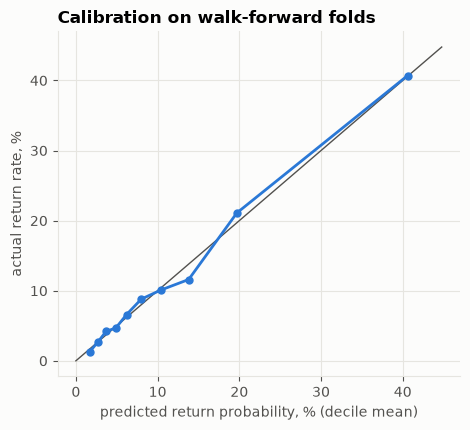

In [12]:
BLUE, INK2, GRID, SURFACE = "#2a78d6", "#52514e", "#e6e5e0", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "axes.edgecolor": GRID,
                     "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2})
fig, ax = plt.subplots(figsize=(4.8, 4.4))
lim = max(rel.predicted.max(), rel.actual.max()) * 100 * 1.1
ax.plot([0, lim], [0, lim], color=INK2, lw=1)
ax.plot(rel.predicted * 100, rel.actual * 100, color=BLUE, lw=2, marker="o", ms=5)
ax.set_xlabel("predicted return probability, % (decile mean)"); ax.set_ylabel("actual return rate, %")
ax.set_title("Calibration on walk-forward folds", loc="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "03_calibration_oof.png", dpi=150); plt.show()

**Reading:** fold calibration slopes are 1.08 / 0.93 / 0.96, and the score spread is the same in all three folds. **Fold 1 is not clearly less confident** (criterion > 0.2), so the calibrator uses all three folds (~6,400 orders, ~710 returns). It is nearly the identity (a = 0.986, b = −0.068), because LR without class weighting is already well calibrated. The reliability table tracks the diagonal from 1.7% to 40.6%.

## 8 · Leak simulation (Jan–Mar 2026 fold)
The chosen model type with the two leaky columns added, trained on Apr–Dec 2025. Scored on Jan–Mar 2026 (a) as exported, (b) with the leaky columns set to what the warehouse sees at dispatch: `INSTALL_BOOKED` for fans / robot vacuums / water purifiers, `NONE` otherwise, no pickup.

In [13]:
rec = training_records(pack["train"], pack["customers"])[sel].reset_index(drop=True)
XL = X.copy()
XL["service_event"] = rec.last_service_event_type.astype(object).to_numpy()
XL["has_pickup"] = rec.pickup_scheduled_at.notna().astype(float).to_numpy()
a, b = FOLDS[2]
tr_m, va_m = (ts < a).to_numpy(), ((ts >= a) & (ts < b)).to_numpy()
fam = XL.loc[va_m, "family"]
dispatch = XL.loc[va_m].copy()
dispatch["service_event"] = np.where(fam.isin(["Ceiling Fan", "Robot Vacuum", "Water Purifier"]), "INSTALL_BOOKED", "NONE")
dispatch["has_pickup"] = 0.0
leak_rows = []
for kind in [REG[CHOSEN]["kind"], "hgb" if REG[CHOSEN]["kind"] == "lr" else "lr"]:
    params = REG[CHOSEN]["params"] if kind == REG[CHOSEN]["kind"] else {}
    feats = REG[CHOSEN]["features"] + ["service_event", "has_pickup"]
    pipe = make_estimator(kind, feats, params, extra_numeric=("has_pickup",), extra_categorical=("service_event",))
    pipe.fit(XL.loc[tr_m, feats], y[tr_m])
    p_exp = pipe.predict_proba(XL.loc[va_m, feats])[:, 1]
    p_dis = pipe.predict_proba(dispatch[feats])[:, 1]
    leak_rows.append({"model": f"{kind} + leaky columns", "AUC as exported (looks perfect)": roc_auc_score(y[va_m], p_exp),
                      "accuracy @0.5 as exported": ((p_exp > 0.5) == y[va_m]).mean(),
                      "AUC at dispatch (real use)": roc_auc_score(y[va_m], p_dis),
                      "share flagged @0.5 at dispatch": (p_dis > 0.5).mean()})
honest = REG[CHOSEN]["aucs"][2]
leak = pd.DataFrame(leak_rows).set_index("model").round(4)
leak.loc["honest chosen model (no leaky columns)"] = [np.nan, np.nan, round(honest, 4), np.nan]
print(f"all-zero accuracy on this fold: {1 - y[va_m].mean():.4f}")
leak

all-zero accuracy on this fold: 0.8838


,AUC as exported (looks perfect),accuracy @0.5 as exported,AUC at dispatch (real use),share flagged @0.5 at dispatch
model,,,,
lr + leaky columns,0.9974,0.9934,0.7106,0.0005
hgb + leaky columns,0.9946,0.9925,0.6806,0.0005
honest chosen model (no leaky columns),NaN,NaN,0.7658,NaN


**Reading: the leak, measured.** The same LR with the two post-dispatch columns scores **AUC 0.997 and 99.3% accuracy** on Jan–Mar 2026, which is exactly the "95%+" the board was promised. Fed what the warehouse actually sees at dispatch, it falls to **0.711**, below the honest model's **0.766**, and flags **0.05%** of orders at 0.5 (it learned "no pickup = no return", and no order has a pickup at dispatch). HGB: 0.995 → 0.681. All-zero accuracy on this fold is 88.4%.

## 9 · Every model tried, and every decision

In [14]:
tried = pd.DataFrame({n: {"kind": r["kind"], **dict(zip(FOLD_NAMES, np.round(r["aucs"], 4))), "mean AUC": round(float(np.mean(r["aucs"])), 4),
                          "mean PR-AUC": round(float(np.mean(r["pr"])), 4), "features": len(r["features"])} for n, r in REG.items()}).T
print(len(tried), "configurations evaluated")
tried

64 configurations evaluated


,kind,Jul-Sep 25,Oct-Dec 25,Jan-Mar 26,mean AUC,mean PR-AUC,features
0 base rate,-,0.5,0.5,0.5,0.5,0.1117,0
1 rule: prior returns x Shield,lookup,0.6729,0.6486,0.6581,0.6599,0.2278,2
2 LR core,lr,0.7996,0.7696,0.7658,0.7783,0.3797,9
3 HGB core (default),hgb,0.7269,0.732,0.7231,0.7273,0.2897,9
lr core,lr,0.7996,0.7696,0.7658,0.7783,0.3797,9
...,...,...,...,...,...,...,...
"hgb tuned {'learning_rate': 0.1, 'max_leaf_nodes': 15, 'max_iter': 300, 'l2_regularization': 1, 'min_samples_leaf': 40}",hgb,0.7663,0.7387,0.7313,0.7454,0.3191,9
"hgb tuned {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'max_iter': 100, 'l2_regularization': 0, 'min_samples_leaf': 40}",hgb,0.7692,0.7454,0.729,0.7479,0.3234,9
"hgb tuned {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'max_iter': 100, 'l2_regularization': 1, 'min_samples_leaf': 40}",hgb,0.7696,0.7452,0.7336,0.7495,0.3229,9
"hgb tuned {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'max_iter': 300, 'l2_regularization': 0, 'min_samples_leaf': 40}",hgb,0.7577,0.7306,0.7064,0.7316,0.2991,9


In [15]:
dec = pd.DataFrame(DECISIONS)[["question", "delta_per_fold", "mean_delta", "folds_improved", "bootstrap_95", "passes"]]
dec

,question,delta_per_fold,mean_delta,folds_improved,bootstrap_95,passes
0,Does LR on core beat the rule baseline?,"[0.1266, 0.121, 0.1077]",0.1184,3,"[0.1013, 0.1386]",True
1,Does HGB on core beat the rule baseline?,"[0.054, 0.0834, 0.0649]",0.0674,3,"[0.0474, 0.0912]",True
2,Add is_gift? (lr),"[0.0048, -0.0008, 0.0043]",0.0028,0,"[-0.0004, 0.0061]",False
3,Add sales_channel? (lr),"[0.0022, 0.0009, 0.0069]",0.0033,1,"[0.0003, 0.007]",False
4,Add tier? (lr),"[0.0007, 0.0006, 0.0006]",0.0006,0,"[-0.0005, 0.0021]",False
5,Add qty? (lr),"[0.0011, -0.0016, -0.0011]",-0.0005,0,"[-0.0022, 0.001]",False
6,Add address_missing? (lr),"[-0.0028, -0.0001, 0.0]",-0.0010,0,"[-0.0023, 0.0]",False
7,Add product_age_days? (lr),"[0.0003, -0.0014, -0.0005]",-0.0005,0,"[-0.0013, 0.0003]",False
8,Add note_present? (lr),"[-0.0001, -0.0011, -0.0002]",-0.0005,0,"[-0.001, 0.0]",False
9,Add note_cat? (lr),"[-0.0046, -0.0067, -0.0037]",-0.0050,0,"[-0.0089, -0.0012]",False


In [16]:
FINAL_CONFIG = {"kind": REG[CHOSEN]["kind"], "features": REG[CHOSEN]["features"], "params": REG[CHOSEN]["params"],
                "monotonic": REG[CHOSEN].get("monotonic", False), "half_life": HALF_LIFE, "calibration_folds": CAL_FOLDS}
print("FINAL_CONFIG =", FINAL_CONFIG)
print("walk-forward AUC per fold:", dict(zip(FOLD_NAMES, REG[CHOSEN]["aucs"].round(4))), "mean", REG[CHOSEN]["aucs"].mean().round(4))
print("walk-forward PR-AUC per fold:", dict(zip(FOLD_NAMES, REG[CHOSEN]["pr"].round(4))))

FINAL_CONFIG = {'kind': 'lr', 'features': ['promised_delivery_days', 'customer_prior_returns', 'customer_prior_orders', 'prior_return_rate', 'has_prior_return', 'discount_pct', 'shield', 'payment_mode', 'family'], 'params': {}, 'monotonic': False, 'half_life': None, 'calibration_folds': [0, 1, 2]}
walk-forward AUC per fold: {'Jul-Sep 25': np.float64(0.7996), 'Oct-Dec 25': np.float64(0.7696), 'Jan-Mar 26': np.float64(0.7658)} mean 0.7783
walk-forward PR-AUC per fold: {'Jul-Sep 25': np.float64(0.4191), 'Oct-Dec 25': np.float64(0.3439), 'Jan-Mar 26': np.float64(0.3761)}


## 10 · Outcome

**Chosen: logistic regression (C = 1) on the 9 core features**: promised delivery days, prior returns, prior orders, prior return rate, has-prior-return, discount, Shield, payment mode, product family. No location, gift, channel, notes or address fields; no recency weighting; sigmoid calibrator fitted on all three folds.

Walk-forward ROC-AUC **0.800 / 0.770 / 0.766 (mean 0.778)**; PR-AUC 0.42 / 0.34 / 0.38 at a ~11% base rate.

Consequences for the service (plan Phase 8, data minimisation): the model needs **no delivery note, no pincode, no city/state, no gift flag, no channel, no qty**. Those inputs leave the API, and unknown-value averaging is only needed for Shield, payment mode and family.

Next: `03b_holdout_and_final.ipynb` scores Apr–Jun 2026 once with this exact configuration, then retrains on all 15 months and saves the model.